# Processing Notebook: PSF Resolution Study
Analysis of subwavelength PEC point scatterer resolution using gprMax zero-offset B-scan simulations.

## Pipeline
1. Parameters & paths
2. Load background + 6 lambda-factor B-scans from `resolution_study/`
3. Background subtraction → scattered field gallery
4. High-frequency filtering
5. Migration: Kirchhoff (depth domain) and Phase-Shift (ImpDAR)
6. Comparison gallery across separations: 2λ, 1λ, 0.5λ, 0.25λ, 0.125λ, 0.0625λ

In [11]:
import gdp
from gdp import data_io
from gdp.core import GPRData
from gdp.data_io import gprdata_to_impdar
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
import copy
import warnings
warnings.filterwarnings('ignore')
from impdar.lib.migrationlib import mig_python
%matplotlib inline

# 1. Parameters & Paths

In [56]:
# Medium & antenna
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns  ≈ 0.16892
v_ice_ms   = v_ice * 1e9                     # m/s   (used by ImpDAR / kirchhoff_migration)
f_c_GHz    = 1.5
wavelength = v_ice / f_c_GHz                 # m  ≈ 0.1126
mean_velocity = v_ice_ms                     # m/s passed to migration functions
t0_ns      = 0.953                           # Ricker peak delay in gprMax [ns]

# Grid & survey
dx_grid      = 7.454e-4   # m  (grid cell size)
n_cells_step = 15         # trace spacing in grid cells
trace_spacing = n_cells_step * dx_grid       # m  ≈ 0.011181

x_survey_start = 0.5   # m
x_survey_end   = 3.5   # m
n_traces = int(round((x_survey_end - x_survey_start) / trace_spacing)) + 1
receiver_positions = x_survey_start + np.arange(n_traces) * trace_spacing  # [m]

# Lambda factors for the resolution study
LAMBDA_FACTORS = [2.0, 1.0]#, 0.5, 0.25, 0.125, 0.0625]

# Target scatterer depth & depth axis for Kirchhoff migration
z_scat        = 0.5                           # m
depth_samples = np.linspace(0.0, 0.7, 400)   # 0 → 0.7 m

# Paths
BASE       = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks')
STUDY_ROOT = BASE / 'resolution_study'
BG_PATH    = BASE / 'B_Scan_Migration_data' / 'bg_bscan_merged.out'

def study_path(factor):
    label = f'{factor:g}'.replace('.', 'p')
    return STUDY_ROOT / f'study_{label}lambda' / 'psf_bscan_merged.out'

# time_axis and extent are filled after loading data
time_axis = None
extent    = None

print(f'λ_ice         = {wavelength*1e3:.2f} mm')
print(f'v_ice         = {v_ice:.5f} m/ns  =  {v_ice_ms:.3e} m/s')
print(f'n_traces      = {n_traces}')
print(f'trace_spacing = {trace_spacing*1e3:.3f} mm')
print(f'Lambda factors: {LAMBDA_FACTORS}')

λ_ice         = 112.61 mm
v_ice         = 0.16891 m/ns  =  1.689e+08 m/s
n_traces      = 269
trace_spacing = 11.181 mm
Lambda factors: [2.0, 1.0]


# 2. Loading Data

In [69]:
component = 'Ey'

def load_gprmax_bscan(path, component='Ey'):
    """Load a gprMax merged .out file.
    Returns (bscan, dt_ns, time_ns) with bscan shape (n_traces, n_time_samples)."""
    with h5py.File(path, 'r') as f:
        dt_s  = float(f.attrs['dt'])
        rxs   = sorted(f['rxs'].keys(), key=lambda s: int(s.replace('rx', '')))
        bscan = np.stack([f['rxs'][r][component][:] for r in rxs], axis=0)
    dt_ns   = dt_s * 1e9
    time_ns = np.arange(bscan.shape[1]) * dt_ns
    return bscan, dt_ns, time_ns

# Load background — gprMax object for metadata, h5py for data
background_gprMax_object = data_io.load_gprmax(str(BG_PATH), rx=1, component=component, return_object=True)

bscan_bg, dt_ns, time_ns_arr = load_gprmax_bscan(BG_PATH, component)
output_background = bscan_bg.T          # (n_time_samples, n_traces) for GPRData

# Update global time/extent parameters
dt_s      = dt_ns * 1e-9               # seconds
time_axis = time_ns_arr * 1e-9         # seconds (for kirchhoff_migration)
extent    = [receiver_positions[0], receiver_positions[-1],
             time_ns_arr[-1], time_ns_arr[0]]

print(f'Background: {output_background.shape}  dt={dt_ns:.6f} ns  t_max={time_ns_arr[-1]:.2f} ns')
print(f'extent (x_start, x_end, t_end_ns, t_start_ns) = {[round(v,4) for v in extent]}')

# Create GPRData object for background
background_GPRData_object = GPRData(output_background, background_gprMax_object.info)

# Load all study B-scans and compute scattered fields (background-subtracted)
study_GPRData_objects     = {}
scattered_GPRData_objects = {}

for factor in LAMBDA_FACTORS:
    path = study_path(factor)
    if not path.exists():
        print(f'WARNING: {path} not found — skipping')
        continue
    bscan_s, _, _ = load_gprmax_bscan(path, component)
    output_study  = bscan_s.T                         # (n_time_samples, n_traces)
    scattered     = output_study - output_background  # background subtraction

    study_GPRData_objects[factor]     = GPRData(output_study, background_gprMax_object.info)
    scattered_GPRData_objects[factor] = GPRData(scattered,    background_gprMax_object.info)
    print(f'Loaded {factor:g}λ  shape={output_study.shape}')

print(f'\nLoaded {len(scattered_GPRData_objects)} scattered datasets.')

Background: (8533, 269)  dt=0.001758 ns  t_max=15.00 ns
extent (x_start, x_end, t_end_ns, t_start_ns) = [np.float64(0.5), np.float64(3.4965), np.float64(15.0005), np.float64(0.0)]
Loaded 2λ  shape=(8533, 269)
Loaded 1λ  shape=(8533, 269)

Loaded 2 scattered datasets.


# 3. B-scan Gallery (Scattered Field)

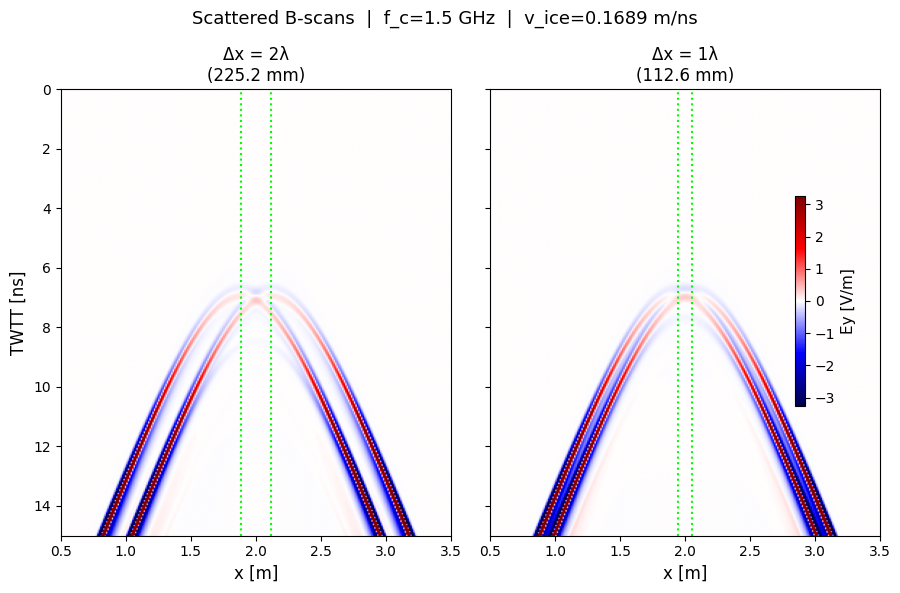

In [70]:
n = len(LAMBDA_FACTORS)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 6), sharey=True)

for ax, factor in zip(axes, LAMBDA_FACTORS):
    if factor not in scattered_GPRData_objects:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
        continue
    data = scattered_GPRData_objects[factor].data
    _p   = np.percentile(np.abs(data), 99)
    im   = ax.imshow(data, aspect='auto', cmap='seismic',
                     vmin=-_p, vmax=_p, extent=extent, origin='upper')

    delta = factor * wavelength
    xs1   = round((2.0 - delta / 2) / dx_grid) * dx_grid
    xs2   = round((2.0 + delta / 2) / dx_grid) * dx_grid
    ax.axvline(xs1, color='lime', ls=':', lw=1.5)
    ax.axvline(xs2, color='lime', ls=':', lw=1.5)

    ax.set_title(f'Δx = {factor:g}λ\n({delta*1e3:.1f} mm)', fontsize=12)
    ax.set_xlabel('x [m]', fontsize=12)
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(15, 0)

axes[0].set_ylabel('TWTT [ns]', fontsize=12)
fig.suptitle(f'Scattered B-scans  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns', fontsize=13)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02).set_label('Ey [V/m]', fontsize=11)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'experiment9_bscan_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Processing

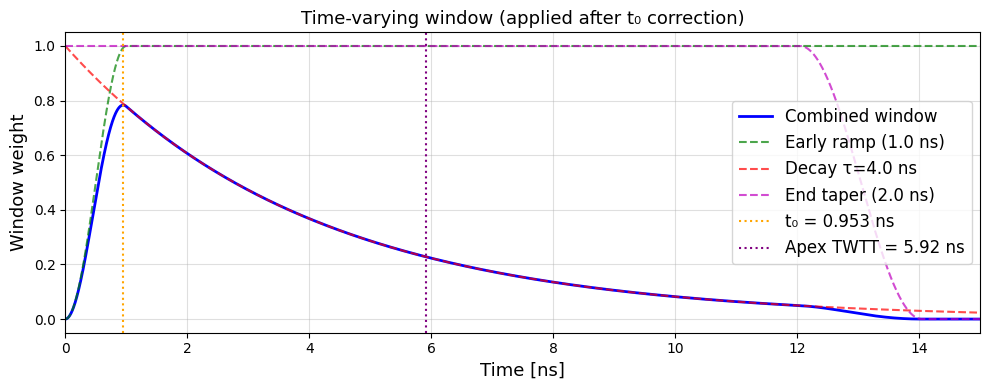

t0 shift        : 542 samples  (0.953 ns)
Early ramp ends : 569 samples  (1.0 ns)
End taper start : sample 6853  (12.05 ns)
Window @ apex   : 0.228  (t=5.92 ns)

Preprocessed 2 datasets.


In [74]:
# --- Preprocessing parameters ---
t0_samp          = int(round(t0_ns / dt_ns))              # ~542 samples  (roll shift)
taper_ramp_ns    = 1.0                                     # early-time cosine ramp width [ns]
taper_ramp_samp  = int(round(taper_ramp_ns / dt_ns))
tau_decay_ns     = 4.0                                     # exponential decay constant [ns]
taper_end_ns     = 2.0                                     # late-time cosine fall width [ns]
taper_end_samp   = int(round(taper_end_ns / dt_ns))

n_t      = output_background.shape[0]
t_arr_ns = np.arange(n_t) * dt_ns

# Rising cosine taper (0 → 1 over first taper_ramp_samp samples)
ramp = np.ones(n_t)
ramp[:taper_ramp_samp] = 0.5 * (1 - np.cos(np.pi * np.arange(taper_ramp_samp) / taper_ramp_samp))

# Exponential decay
decay = np.exp(-t_arr_ns / tau_decay_ns)

# Falling cosine taper (1 → 0) ending at the t0-zeroed boundary, then 0
# Covers [n_t - t0_samp - taper_end_samp  :  n_t - t0_samp]
end_ramp = np.ones(n_t)
fall_start = n_t - t0_samp - taper_end_samp
end_ramp[fall_start : n_t - t0_samp] = 0.5 * (1 + np.cos(
    np.pi * np.arange(taper_end_samp) / taper_end_samp))
end_ramp[n_t - t0_samp:] = 0.0   # matches the hard zero from np.roll cleanup

window = ramp * decay * end_ramp   # combined window

# Plot window
apex_t_ns = 2.0 * z_scat / v_ice
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_arr_ns, window,   'b-',  lw=2,   label='Combined window')
ax.plot(t_arr_ns, ramp,     'g--', lw=1.5, alpha=0.7, label=f'Early ramp ({taper_ramp_ns} ns)')
ax.plot(t_arr_ns, decay,    'r--', lw=1.5, alpha=0.7, label=f'Decay τ={tau_decay_ns} ns')
ax.plot(t_arr_ns, end_ramp, 'm--', lw=1.5, alpha=0.7, label=f'End taper ({taper_end_ns} ns)')
ax.axvline(t0_ns,     color='orange', ls=':', lw=1.5, label=f't₀ = {t0_ns} ns')
ax.axvline(apex_t_ns, color='purple', ls=':', lw=1.5, label=f'Apex TWTT = {apex_t_ns:.2f} ns')
ax.set_xlabel('Time [ns]', fontsize=13)
ax.set_ylabel('Window weight', fontsize=13)
ax.set_title('Time-varying window (applied after t₀ correction)', fontsize=13)
ax.set_xlim(0, 15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f't0 shift        : {t0_samp} samples  ({t0_ns:.3f} ns)')
print(f'Early ramp ends : {taper_ramp_samp} samples  ({taper_ramp_ns:.1f} ns)')
print(f'End taper start : sample {fall_start}  ({fall_start * dt_ns:.2f} ns)')
print(f'Window @ apex   : {np.interp(apex_t_ns, t_arr_ns, window):.3f}  (t={apex_t_ns:.2f} ns)')

# Apply to each scattered dataset
preprocessed_GPRData_objects = {}
for factor in LAMBDA_FACTORS:
    if factor not in scattered_GPRData_objects:
        continue
    raw = scattered_GPRData_objects[factor].data.copy()
    # 1. Time-zero correction
    data_t0 = np.roll(raw, -t0_samp, axis=0)
    data_t0[-t0_samp:, :] = 0.0
    # 2. Apply combined window (early ramp × exponential decay × end taper)
    data_prep = data_t0 * window[:, np.newaxis]
    preprocessed_GPRData_objects[factor] = GPRData(data_prep, background_gprMax_object.info)

print(f'\nPreprocessed {len(preprocessed_GPRData_objects)} datasets.')

In [75]:
def apply_hard_cutoff(data, dt, cutoff_freq=5e9):
    """Hard bandpass: zero all spectral components above cutoff_freq. dt in seconds.
    Returns (filtered, fft_freqs, orig_spectrum, filt_spectrum)."""
    fft_data      = np.fft.rfft(data, axis=0)
    fft_freqs     = np.fft.rfftfreq(data.shape[0], d=dt)
    orig_spectrum = np.abs(fft_data)
    fft_filtered  = fft_data * (fft_freqs <= cutoff_freq)[:, np.newaxis]
    filt_spectrum = np.abs(fft_filtered)
    filtered      = np.fft.irfft(fft_filtered, n=data.shape[0], axis=0)
    return filtered, fft_freqs, orig_spectrum, filt_spectrum

cutoff_freq = 5e9   # 5 GHz

filtered_GPRData_objects = {}
processed = []   # list of dicts used by the visualization cell below

for factor in LAMBDA_FACTORS:
    if factor not in preprocessed_GPRData_objects:
        continue
    raw = preprocessed_GPRData_objects[factor].data.copy()
    filtered, freqs, orig_spec, filt_spec = apply_hard_cutoff(raw, dt_s, cutoff_freq)
    filtered_GPRData_objects[factor] = GPRData(filtered, background_gprMax_object.info)

    delta = factor * wavelength
    processed.append({
        'title':     f'Δx={factor:g}λ ({delta*1e3:.1f} mm)',
        'original':  raw,
        'filtered':  filtered,
        'freqs':     freqs,
        'orig_spec': orig_spec,
        'filt_spec': filt_spec,
    })

print(f'Applied {cutoff_freq/1e9:.0f} GHz hard cutoff to {len(filtered_GPRData_objects)} datasets.')

Applied 5 GHz hard cutoff to 2 datasets.


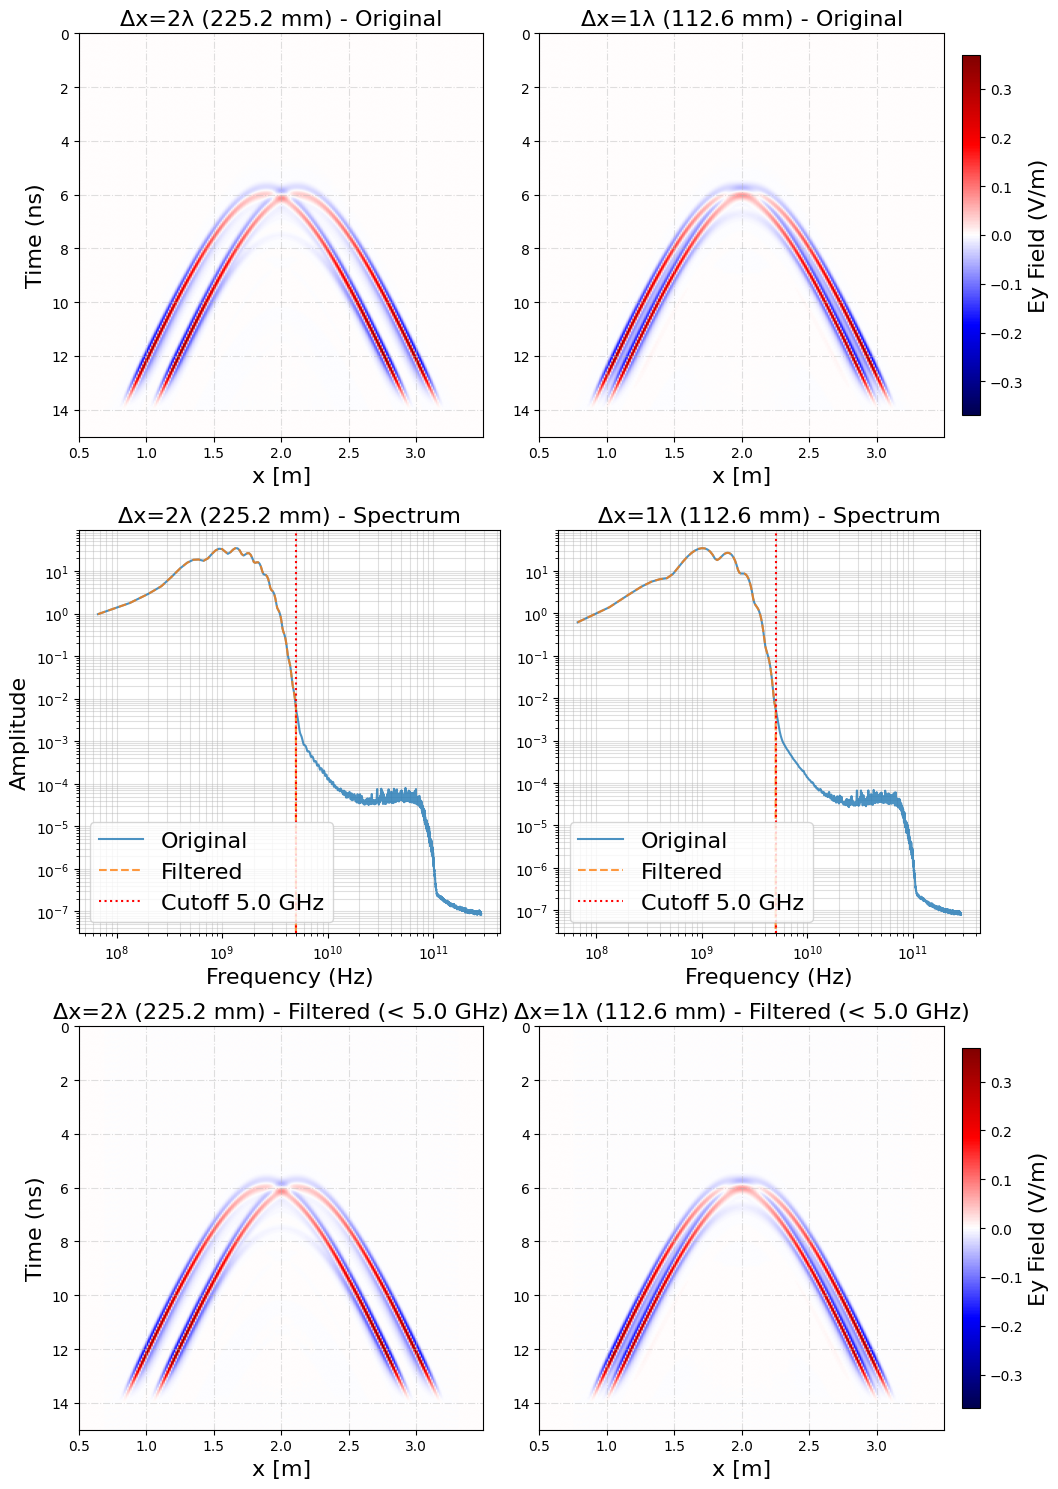

In [76]:
# Visualization
# Compute common color scales for spatial plots
originals     = [p['original'] for p in processed]
filtered_list = [p['filtered'] for p in processed]

vmin_row0 = -np.amax([np.abs(d).max() for d in originals])
vmax_row0 =  np.amax([np.abs(d).max() for d in originals])

vmin_row2 = -np.amax([np.abs(d).max() for d in filtered_list])
vmax_row2 =  np.amax([np.abs(d).max() for d in filtered_list])

# Plot: 3 rows x N cols
n_cols = len(processed)
fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 15))

for col, p in enumerate(processed):
    title = p['title']

    # Row 1: Original Spatial
    im0 = axes[0, col].imshow(p['original'], aspect='auto', cmap='seismic', extent=extent,
                              vmin=vmin_row0, vmax=vmax_row0)
    axes[0, col].set_title(f'{title} - Original', fontsize=16)
    axes[0, col].set_xlabel('x [m]', fontsize=16)
    if col == 0:
        axes[0, col].set_ylabel('Time (ns)', fontsize=16)
    axes[0, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

    # Row 2: Frequency Spectrum (Log-Log)
    # Average spectrum across all traces, ignoring DC component (index 0)
    avg_orig_spec = np.mean(p['orig_spec'], axis=1)
    avg_filt_spec = np.mean(p['filt_spec'], axis=1)

    # Slice to remove 0 Hz (DC) for log plot
    freqs_slice = p['freqs'][1:]
    orig_slice  = avg_orig_spec[1:]
    filt_slice  = avg_filt_spec[1:]

    axes[1, col].loglog(freqs_slice, orig_slice, label='Original', alpha=0.8)
    axes[1, col].loglog(freqs_slice, filt_slice, '--', label='Filtered', alpha=0.8)
    axes[1, col].axvline(x=cutoff_freq, color='r', linestyle=':', label=f'Cutoff {cutoff_freq/1e9} GHz')

    axes[1, col].set_title(f'{title} - Spectrum', fontsize=16)
    axes[1, col].set_xlabel('Frequency (Hz)', fontsize=16)
    if col == 0:
        axes[1, col].set_ylabel('Amplitude', fontsize=16)
    axes[1, col].legend(fontsize=16)
    axes[1, col].grid(True, which="both", ls="-", alpha=0.4)

    # Row 3: Filtered Spatial
    im2 = axes[2, col].imshow(p['filtered'], aspect='auto', cmap='seismic', extent=extent,
                              vmin=vmin_row2, vmax=vmax_row2)
    axes[2, col].set_title(f'{title} - Filtered (< {cutoff_freq/1e9} GHz)', fontsize=16)
    axes[2, col].set_xlabel('x [m]', fontsize=16)
    if col == 0:
        axes[2, col].set_ylabel('Time (ns)', fontsize=16)
    axes[2, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

plt.tight_layout()

# Colorbars for spatial rows
cbar1 = fig.colorbar(im0, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ey Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im2, ax=axes[2, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ey Field (V/m)', fontsize=16)

# Save image
path = STUDY_ROOT / 'experiment9_HighFreq_Removed_LogLog.png'
plt.savefig(fname=path, bbox_inches='tight')
plt.show()

# 5. Migration

In [80]:
# Convert filtered GPRData objects to ImpDAR RadarData objects
impdar_objects = {}

for factor in LAMBDA_FACTORS:
    if factor not in filtered_GPRData_objects:
        continue
    gpr = filtered_GPRData_objects[factor]
    imp = gprdata_to_impdar(gpr)
    imp.dt          = dt_s                                                              # s
    imp.snum        = gpr.data.shape[0]                                                 # time samples
    imp.tnum        = gpr.data.shape[1]                                                 # traces
    imp.travel_time = time_axis * 1e6                                                   # s → µs
    imp.dist        = receiver_positions / 1000                                         # m → km (for display)
    # trace_int must be in METRES: migrationPhaseShift computes kx = 2π/trace_int [rad/m],
    # which must be dimensionally consistent with vmig/w [m/s / (rad/s) = m/rad].
    # Setting trace_int in km makes kx 1000× too small → vkx² >> w² → all modes evanescent → horizontal bands.
    imp.trace_int   = (receiver_positions[-1] - receiver_positions[0]) / (imp.tnum - 1)  # m
    impdar_objects[factor] = imp
    print(f'ImpDAR {factor:g}λ: {imp.snum} samples × {imp.tnum} traces  |  trace_int={imp.trace_int*1e3:.3f} mm')

ImpDAR 2λ: 8533 samples × 269 traces  |  trace_int=11.181 mm
ImpDAR 1λ: 8533 samples × 269 traces  |  trace_int=11.181 mm


## Kirchhoff Migration

In [81]:
kirchhoff_migrated = {}
depth_max_kh = mean_velocity * time_ns_arr[-1] * 1e-9 / 2   # m  (one-way depth at max TWTT)

for factor in LAMBDA_FACTORS:
    if factor not in impdar_objects:
        continue
    imp_copy = copy.deepcopy(impdar_objects[factor])
    result   = mig_python.migrationKirchhoff(imp_copy, mean_velocity, nearfield=True)
    kirchhoff_migrated[factor] = result
    print(f'Kirchhoff {factor:g}λ: {result.data.shape}')

Kirchhoff Migration (diffraction summation) of 8533x269 matrix
Migrating trace number:
0, 1, 2, 3, 

KeyboardInterrupt: 

In [ ]:
# --- Plot: before (scattered B-scan) and after Kirchhoff ---
n = len(LAMBDA_FACTORS)
fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 10), sharex='col')

for col, factor in enumerate(LAMBDA_FACTORS):
    delta = factor * wavelength
    xs1   = round((2.0 - delta / 2) / dx_grid) * dx_grid
    xs2   = round((2.0 + delta / 2) / dx_grid) * dx_grid

    # Row 0: scattered B-scan (before)
    if factor in scattered_GPRData_objects:
        d  = scattered_GPRData_objects[factor].data
        _p = np.percentile(np.abs(d), 99)
        axes[0, col].imshow(d, aspect='auto', cmap='seismic',
                            vmin=-_p, vmax=_p, extent=extent, origin='upper')
        axes[0, col].axvline(xs1, color='lime', ls=':', lw=1.2)
        axes[0, col].axvline(xs2, color='lime', ls=':', lw=1.2)
        axes[0, col].set_xlim(1.5, 2.5)
        axes[0, col].set_ylim(9.5, 4.5)
    axes[0, col].set_title(f'Δx = {factor:g}λ\n({delta*1e3:.1f} mm)', fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Before Migration\nTWTT [ns]', fontsize=11)

    # Row 1: Kirchhoff depth image (after)
    if factor in kirchhoff_migrated:
        img = kirchhoff_migrated[factor].data
        _p  = np.percentile(np.abs(img), 99)
        im1 = axes[1, col].imshow(
            img, aspect='auto', cmap='seismic', vmin=-_p, vmax=_p,
            extent=[receiver_positions[0], receiver_positions[-1], depth_max_kh, 0])
        axes[1, col].plot(xs1, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].plot(xs2, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].set_xlim(1.5, 2.5)
        axes[1, col].set_ylim(0.7, 0.3)
    axes[1, col].set_xlabel('x [m]', fontsize=11)
    if col == 0:
        axes[1, col].set_ylabel('After Kirchhoff\nDepth [m]', fontsize=11)

fig.suptitle(f'Kirchhoff Migration (ImpDAR)  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns', fontsize=13)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'experiment9_kirchhoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

import numpy as np
import copy
import time
from numba import njit, prange

@njit(parallel=True)
def fast_kirchhoff_loop(data, gradD, tnum, snum, dist, zs, zs2, tt_0, dt, vel, max_travel_time, nearfield):
    migdata = np.zeros_like(data)
    
    # Iterate over all traces and depth samples in parallel
    for xi in prange(tnum):
        for ti in range(snum):
            if zs[ti] == 0:
                continue
                
            integral = 0.0
            
            for tr in range(tnum):
                # Distance to current surface receiver
                rs = np.sqrt((dist[tr] - dist[xi])**2 + zs2[ti])
                
                t_travel = 2.0 * rs / vel
                if t_travel > max_travel_time:
                    continue
                
                # Math-based index lookup (replaces slow np.argmin)
                Didx = int(round((t_travel - tt_0) / dt))
                
                if Didx < 0 or Didx >= snum:
                    continue
                    
                costheta = zs[ti] / rs
                
                # Far-field integration (ImpDAR uses Yilmaz 4.5)
                integral += gradD[Didx, tr] * costheta / vel
                
                # Near-field integration
                if nearfield:
                    integral += data[Didx, tr] * costheta / (rs**2)
                    
            migdata[ti, xi] = integral / (2.0 * np.pi)
            
    return migdata

def fast_migration_kirchhoff(imp_obj, mean_velocity, nearfield=True):
    """
    Drop-in Numba replacement for mig_python.migrationKirchhoff.
    Runs identically to ImpDAR's native math but radically faster.
    """
    start = time.time()
    
    # 1. Prepare arrays identically to ImpDAR
    data = imp_obj.data.astype(np.float64)
    tt_sec = imp_obj.travel_time / 1e6
    gradD = np.gradient(data, tt_sec, axis=0).astype(np.float64)
    
    max_travel_time = np.max(tt_sec)
    dt = tt_sec[1] - tt_sec[0]
    tt_0 = tt_sec[0]
    
    # Pre-cache depth mappings
    zs = mean_velocity * tt_sec / 2.0
    zs2 = zs**2
    dist_m = imp_obj.dist * 1e3
    
    # 2. Run JIT loop
    migrated_data = fast_kirchhoff_loop(
        data, gradD, int(imp_obj.tnum), int(imp_obj.snum),
        dist_m.astype(np.float64), zs.astype(np.float64), zs2.astype(np.float64),
        float(tt_0), float(dt), float(mean_velocity), float(max_travel_time), nearfield
    )
    
    # 3. Resemble ImpDAR's expected return object
    out_obj = copy.deepcopy(imp_obj)
    out_obj.data = migrated_data 
    print(f"JIT Kirchhoff completed in {time.time() - start:.3f} s")
    
    return out_obj

In [85]:
# result = mig_python.migrationKirchhoff(imp_copy, mean_velocity, nearfield=True)
result = fast_migration_kirchhoff(imp_copy, mean_velocity, nearfield=True)

JIT Kirchhoff completed in 1.845 s


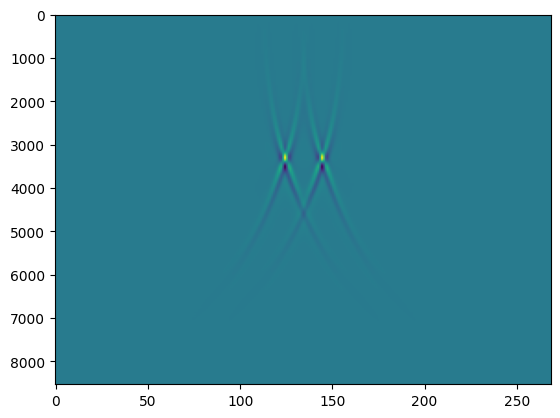

In [89]:
plt.imshow(result.data, aspect='auto')

## Phase-Shift Migration

In [65]:
time_ns_arr

array([0.00000000e+00, 1.75814094e-03, 3.51628189e-03, ...,
       1.49969422e+01, 1.49987004e+01, 1.50004585e+01], shape=(8533,))

In [66]:
mean_velocity / (3e8 / np.sqrt(6))

np.float64(1.3791763347759278)

Phase-Shift Migration of 8533x269 matrix
Constant velocity 168.9139142761467 m/usec
Frequency: Frequency: 
0 MHz , 3471 MHz , 6943 MHz , 10414 MHz , 13886 MHz , 17357 MHz , 20829 MHz , 24301 MHz , 27772 MHz , 31244 MHz , 34715 MHz , 38187 MHz , 41658 MHz , 45130 MHz , 48602 MHz , 52073 MHz , 55545 MHz , 59016 MHz , 62488 MHz , 65959 MHz , 69431 MHz , 72903 MHz , 76374 MHz , 79846 MHz , 83317 MHz , 86789 MHz , 90260 MHz , 93732 MHz , 97204 MHz , 100675 MHz , 104147 MHz , 107618 MHz , 111090 MHz , 114561 MHz , 118033 MHz , 121505 MHz , 124976 MHz , 128448 MHz , 131919 MHz , 135391 MHz , 138862 MHz , 142334 MHz , 145806 MHz , 149277 MHz , 152749 MHz , 156220 MHz , 159692 MHz , 163163 MHz , 166635 MHz , 170107 MHz , 173578 MHz , 177050 MHz , 180521 MHz , 183993 MHz , 187464 MHz , 190936 MHz , 194408 MHz , 197879 MHz , 201351 MHz , 204822 MHz , 208294 MHz , 211765 MHz , 215237 MHz , 218709 MHz , 222180 MHz , 225652 MHz , 229123 MHz , 232595 MHz , 236067 MHz , 239538 MHz , 243010 MHz , 24648

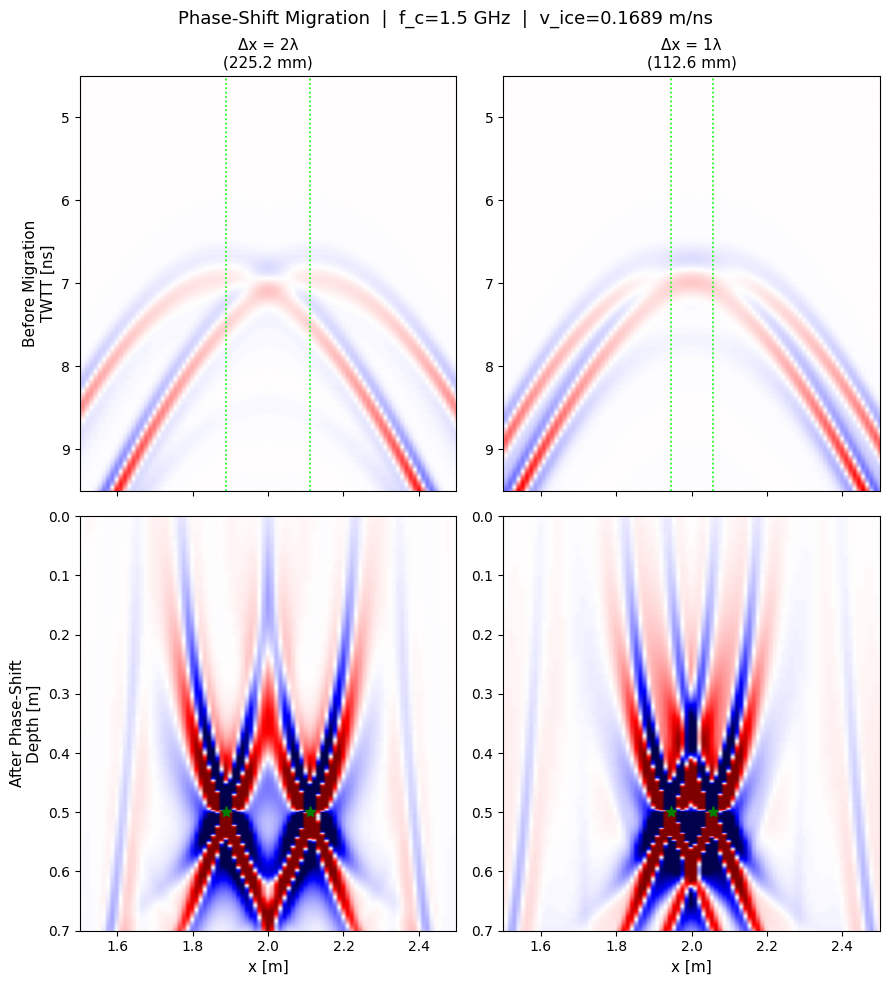

In [67]:
htaper = 75
vtaper = 75

# Maximum one-way depth reachable in this survey
depth_max_ps = mean_velocity * 1e-9 * time_ns_arr[-1] / 2   # m

phaseshift_migrated = {}

for factor in LAMBDA_FACTORS:
    if factor not in impdar_objects:
        continue
    imp_copy = copy.deepcopy(impdar_objects[factor])
    result   = mig_python.migrationPhaseShift(imp_copy, htaper=htaper, vtaper=vtaper, vel=mean_velocity)
    phaseshift_migrated[factor] = result
    print(f'Phase-shift {factor:g}λ: {result.data.shape}')

# --- Plot: before and after Phase-Shift ---
n = len(LAMBDA_FACTORS)
fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 10), sharex='col')

for col, factor in enumerate(LAMBDA_FACTORS):
    delta = factor * wavelength
    xs1   = round((2.0 - delta / 2) / dx_grid) * dx_grid
    xs2   = round((2.0 + delta / 2) / dx_grid) * dx_grid

    # Row 0: scattered B-scan (before)
    if factor in scattered_GPRData_objects:
        d  = scattered_GPRData_objects[factor].data
        _p = np.percentile(np.abs(d), 99)
        axes[0, col].imshow(d, aspect='auto', cmap='seismic',
                            vmin=-_p, vmax=_p, extent=extent, origin='upper')
        axes[0, col].axvline(xs1, color='lime', ls=':', lw=1.2)
        axes[0, col].axvline(xs2, color='lime', ls=':', lw=1.2)
        axes[0, col].set_xlim(1.5, 2.5)
        axes[0, col].set_ylim(9.5, 4.5)
    axes[0, col].set_title(f'Δx = {factor:g}λ\n({delta*1e3:.1f} mm)', fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Before Migration\nTWTT [ns]', fontsize=11)

    # Row 1: Phase-Shift depth image (after)
    if factor in phaseshift_migrated:
        imp_mig = phaseshift_migrated[factor]
        _p      = np.percentile(np.abs(imp_mig.data), 99)
        im1     = axes[1, col].imshow(
            imp_mig.data, aspect='auto', cmap='seismic', vmin=-_p, vmax=_p,
            extent=[receiver_positions[0], receiver_positions[-1], depth_max_ps, 0])
        axes[1, col].plot(xs1, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].plot(xs2, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].set_xlim(1.5, 2.5)
        axes[1, col].set_ylim(0.7, 0.0)
    axes[1, col].set_xlabel('x [m]', fontsize=11)
    if col == 0:
        axes[1, col].set_ylabel('After Phase-Shift\nDepth [m]', fontsize=11)

fig.suptitle(f'Phase-Shift Migration  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns', fontsize=13)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'experiment9_phaseshift.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Migration Comparison Gallery

In [ ]:
# Side-by-side: Kirchhoff (row 0) vs Phase-Shift (row 1)
n = len(LAMBDA_FACTORS)
fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 10))

for col, factor in enumerate(LAMBDA_FACTORS):
    delta = factor * wavelength
    xs1   = round((2.0 - delta / 2) / dx_grid) * dx_grid
    xs2   = round((2.0 + delta / 2) / dx_grid) * dx_grid

    # Row 0: Kirchhoff
    if factor in kirchhoff_migrated:
        img = kirchhoff_migrated[factor].data
        _p  = np.percentile(np.abs(img), 99)
        im0 = axes[0, col].imshow(
            img, aspect='auto', cmap='seismic', vmin=-_p, vmax=_p,
            extent=[receiver_positions[0], receiver_positions[-1], depth_max_kh, 0])
        axes[0, col].plot(xs1, z_scat, 'g*', ms=8, zorder=5)
        axes[0, col].plot(xs2, z_scat, 'g*', ms=8, zorder=5)
        axes[0, col].set_xlim(1.5, 2.5)
        axes[0, col].set_ylim(0.7, 0.3)
    axes[0, col].set_title(f'Δx = {factor:g}λ\n({delta*1e3:.1f} mm)', fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Kirchhoff\nDepth [m]', fontsize=11)

    # Row 1: Phase-Shift
    if factor in phaseshift_migrated:
        imp_mig = phaseshift_migrated[factor]
        _p      = np.percentile(np.abs(imp_mig.data), 99)
        im1     = axes[1, col].imshow(
            imp_mig.data, aspect='auto', cmap='seismic', vmin=-_p, vmax=_p,
            extent=[receiver_positions[0], receiver_positions[-1], depth_max_ps, 0])
        axes[1, col].plot(xs1, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].plot(xs2, z_scat, 'g*', ms=8, zorder=5)
        axes[1, col].set_xlim(1.5, 2.5)
        axes[1, col].set_ylim(0.7, 0.0)
    axes[1, col].set_xlabel('x [m]', fontsize=11)
    if col == 0:
        axes[1, col].set_ylabel('Phase-Shift\nDepth [m]', fontsize=11)

fig.suptitle(
    f'Kirchhoff vs Phase-Shift (ImpDAR)  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns',
    fontsize=13)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'experiment9_migration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()